# **Classification Course**


---

In this course, you will learn how to apply ***the supervised learning workflow (explained in Section 4 of the lecture) to classification problems***. We will use **"decision tree" model** throughout the exercises and look at each step of the workflow: ***understanding the data, processing data, model building, and model evaluation***. The goal is to practice the knowledge required for each step depending on the level.


# Level 3 (★★★)

---
In Level 3, we will discuss merging data. So far, we have processed a single table and built a model, but this time, we will learn about how to merge two tables. Merging data is necessary when extracting data from different databases or when data is stored separately to avoid overlapping of the data.


## 3.1. Understanding Data


This time, we will work on a classification task using not only the appearance but also information about the odor of poisonous mushrooms. As usual, download the data on the appearance of mushrooms and the odor data from the following links, upload them to the specified location, and try reading the files. Then, display and check the contents of the odor data we will be using.

[Mushroom_Appearence_Data.csv](https://drive.google.com/file/d/19NKE8PgEhgE9b5WZnFgmWkZ-D2DR2NIe/view?usp=drive_link)

[Mushroom_Odor_Data.csv](https://drive.google.com/file/d/1FTM968kKuqivrbjSk-JeNBaIHqYL6U_b/view?usp=drive_link)

Both datasets are from the UC Irvine Machine Learning Repository. (https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data)

In [ ]:
import pandas as pd

df1 = pd.read_csv('Mushroom_Appearence_Data.csv')
df2 = pd.read_csv('Mushroom_Odor_Data.csv')

df2.head()

,ID,odor
0,2,a
1,3,l
2,4,p
3,5,n
4,6,a


We can see that the odor data contains information about ID and odor. Next, let's check the number of data points.

In [ ]:
print('Number of appearence data', len(df1))
print('Number of odor data', len(df2))

Number of appearence data 8124
Number of odor data 8120


You should see that there are about four fewer pieces of odor data compared to the number of appearance data.

Let's use the `unique()` method that we learned in Level 1 to check the different types of odors.

In [ ]:
# Check the types of odors
df2['odor'].unique()

array(['a', 'l', 'p', 'n', 'f', 'c', 'y', 's', 'm'], dtype=object)

We can see that there are 9 types of data included. The meanings of the abbreviations are shown in the table below:

| Abbreviation | Meaning |
|--------------|---------|
| p            | pungent |
| a            | almond  |
| l            | anise   |
| n            | none    |
| f            | foul    |
| c            | creosote|
| y            | fishy   |
| s            | spicy   |
| m            | musty   |

The odor and appearance datasets share a common ID column, meaning that any rows with the same ID describe the same mushroom. By merging these two datasets on their IDs, we can build a classification model that predicts whether a given mushroom is poisonous using features like bruises, color, and odor.

## 3.2. Processing Data

To merge DataFrame objects, you can use the `merge` function in pandas. When you pass the DataFrames as arguments, it will automatically recognize columns with identical names such as the ID column and merges the data on that shared column by default.

In [ ]:
# Inner join (appearance data df1 + odor data df2)
df = pd.merge(df1, df2)
df.head()

,ID,bruises,cap_color,poison,odor
0,2,Y,y,N,a
1,3,Y,w,N,l
2,4,NaN,w,Y,p
3,5,NaN,g,N,n
4,6,NaN,y,N,a


In [ ]:
len(df)

8120

After merging, the number of data points is smaller than the number of original appearance data points, and is the same as the number of odor data points. This reduction in data points is because the merge function defaults to an inner join. Next, let's examine the differences in merging methods.

>**Different types of merging**
>
>**Inner join**, **left outer join**, and **full outer join** are commonly used methods for merging table data. In an **inner join**, data that matches a specific column between different tables is merged, and rows that do not match are deleted. In a **left outer join**, all data from the left table will be kept. If a given row lacks a match in the right table, the right-side columns are filled with missing values. **Full outer join** combines all data, treating rows that do not match in both tables as missing values.

With the `merge()` function in pandas, you can switch the merging style by specifying `inner` (for inner join), `left` (for left outer join), and `outer` (for full outer join) using the `how` argument.

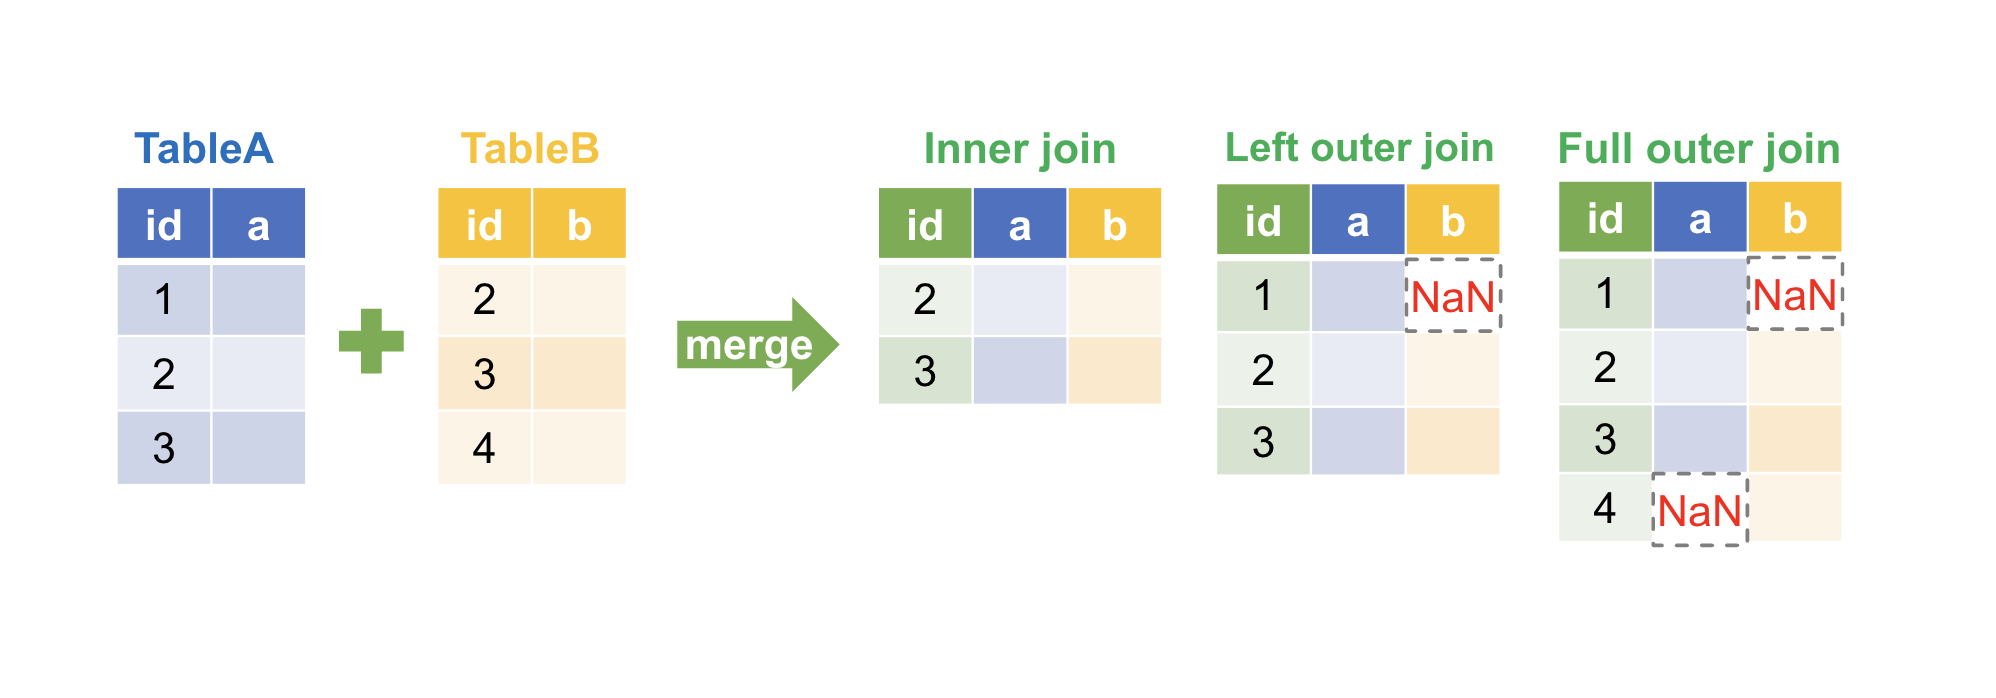

In this case, since the number of data points after performing an inner join matches the number of odor data points, it can be inferred that all odor data IDs are included in the appearance data IDs. To investigate whether the data in a specific column is contained in another column, you can use the `isin` method. In the following code cell, we are checking if each data in the ID column of `df1` is included in the data of the ID column of `df2`.

In [ ]:
# Check if each data in the ID column of df1 is included in the data of the ID column of df2 (Included➤True, Not included➤False)
se_id1_is_in_id2 = df1['ID'].isin(df2['ID'])
se_id1_is_in_id2.head()

,ID
0,False
1,True
2,True
3,True
4,True


The `isin()` method returns a Series object of boolean (bool) type values, with True for data included in the argument in parentheses and False for data not included. Let's check how many data points in the ID column of df1 are not included. We can use the `sum()` method to count the number of True values in a Series object with boolean values.

However, to examine the number of False values (data not included), we will invert the Boolean Series first using the operator **~**, which flips every True to False and every False to True. After that, calling `sum()` method on the inverted Series gives the number of data points that are not included.

In [ ]:
se_id1_is_not_in_id2 = ~se_id1_is_in_id2
se_id1_is_not_in_id2.head()

,ID
0,True
1,False
2,False
3,False
4,False


In [ ]:
se_id1_is_not_in_id2.sum()

np.int64(4)

In [ ]:
# Get the number of IDs not included in df1
# Create a Series indicating whether df2’s IDs are in df1
se_id2_is_in_id1 = df2['ID'].isin(df1['ID'])
# Create a Series indicating whether df2’s IDs are not in df1
se_id2_is_not_in_id1 = ~se_id2_is_in_id1
# Get the count of IDs in df2 that are not in df1
se_id2_is_not_in_id1.sum()

np.int64(0)

Since there are zero records of ID from `df2` that are not included in `df1`, we can confirm that all IDs in `df2` are included in `df1`.

Next, we want to identify which IDs in `df1` are not included in `df2`. Since we already have a Series of boolean for the data that are not included, let's use the `loc[]` attribute learned in Level 2 to extract this information.

In [ ]:
df1.loc[se_id1_is_not_in_id2, 'ID']

,ID
0,1
616,617
2386,2387
6080,6081


We can confirm that 4 IDs (1, 617, 2387, 6081) were not included in `df2`. Therefore, in the inner join, the data was reduced by 4 after the merge.

Now, let's see what happens to the number of data entries when we perform a left outer join. By specifying `left` for the `how` argument, a left outer join is performed on the appearance data (left) with the odor data (right).

In [ ]:
df_left = pd.merge(df1, df2, how='left')
df_left.head()

,ID,bruises,cap_color,poison,odor
0,1,Y,n,Y,NaN
1,2,Y,y,N,a
2,3,Y,w,N,l
3,4,NaN,w,Y,p
4,5,NaN,g,N,n


In [ ]:
len(df_left)

8124

Above, we see that the odor of ID 1 is now `NaN`. We also see that the total number of data points remains 8124.

Now, let's check the missing values. We can see that there are 4 rows with missing `odor` values.

In [ ]:
df_left.isnull().sum()

,0
ID,0
bruises,1624
cap_color,0
poison,0
odor,4


All IDs in `df2` also appear in `df1`, so a left outer join would yield the same result as a full outer join. Therefore, we’ll proceed with the DataFrame produced by the inner join. Before building the model, we’ll call `dropna()` to remove any remaining missing values from the appearance data.

In [ ]:
df_drop = df.dropna()
df_drop.head()

,ID,bruises,cap_color,poison,odor
0,2,Y,y,N,a
1,3,Y,w,N,l
5,7,Y,w,N,a
6,8,Y,w,N,l
7,9,Y,w,Y,p


Now, let's apply dummy encoding to the merged DataFrame. This includes the newly added column (odor) as well.

In [ ]:
df_dummy = pd.get_dummies(df_drop[['bruises', 'cap_color', 'odor']], drop_first= True)

Then, assign the features to variable `x` and the label to variable `y`, then separate them into training data and test data.

In [ ]:
from sklearn.model_selection import train_test_split

x = df_dummy
y = df_drop['poison']

# Splitting the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y)

## 3.3. Model Building and Evaluation

Next, we will build a model as usual and then evaluate it.

In [ ]:
from sklearn.tree import  DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train, y_train)

test_score = model.score(x_test, y_test)
round(test_score, 3)

0.99

The accuracy rate has exceeded 90%. By using a dataset combining appearance data with odor data, the accuracy of the predictions improved. This concludes the content of Level 3. In the final exercise problems, you will practice combining two tabular datasets using different merging methods to observe how the merged data changes and deepen your understanding of merging techniques.

## 3.4. Practice Problems

**Q3-1.** How many rows will the resulting table have if you perform an inner join based on the column 'column2', between the following two tables TableA and TableB? Use pandas DataFrame to verify.

TableA

|column1| column2|
|------|------|
|1 | b |
|2 | t |
|3 | a |

TableB

|column2 | column3|
|------|------|
|a | 0.1 |
|b | 0.5 |
|c | 0.7 |

**Q3-2.** How many rows will the resulting table have if you perform an left outer join with TableA as the left table based on the column 'column2'? Use pandas DataFrame to verify.

**Q3-3.** How many rows will the resulting table have if you perform an full outer join with TableA based on the column 'column2'? Use pandas DataFrame to verify.

**Q3-4.** Check how many values in the 'column2' of the DataFrame produced by the full outer join in Q3-3 also appear in the 'column2' of the DataFrame generated by the inner join in Q3-1.